EXERCISE 1

Implement an Importance Sampler

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Target PDF (Johnson's Su Distribution)
def target_pdf(x):
    return np.sqrt(2) / np.sqrt(np.pi * (1 + (x - 1) ** 2)) * np.exp(-0.5 * (3 + 2 * np.arcsinh(x - 1)) ** 2)

# Proposal PDF (Standard Normal)
def proposal_pdf(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

# Importance Sampling
def importance_sampling(L):
    samples = np.random.normal(0, 1, L)  # Draw samples from N(0, 1)
    weights = target_pdf(samples) / proposal_pdf(samples)
    return samples, weights

# Generate 1000 samples
L = 1000
samples, weights = importance_sampling(L)


Plot Histogram of Samples and PDFs

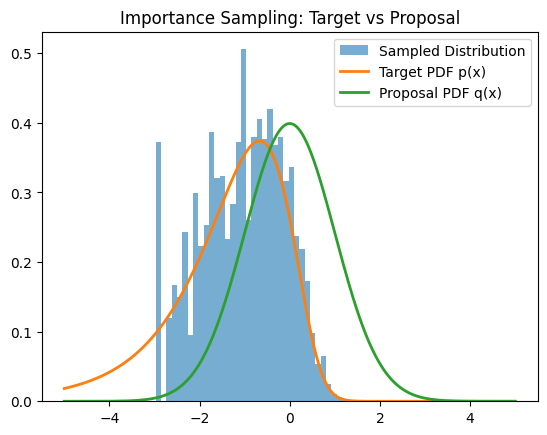

In [2]:
x = np.linspace(-5, 5, 1000)
target = target_pdf(x)
proposal = proposal_pdf(x)

plt.hist(samples, bins=50, weights=weights, density=True, alpha=0.6, label="Sampled Distribution")
plt.plot(x, target, label="Target PDF p(x)", linewidth=2)
plt.plot(x, proposal, label="Proposal PDF q(x)", linewidth=2)
plt.legend()
plt.title("Importance Sampling: Target vs Proposal")
plt.show()


Effect of Increasing L

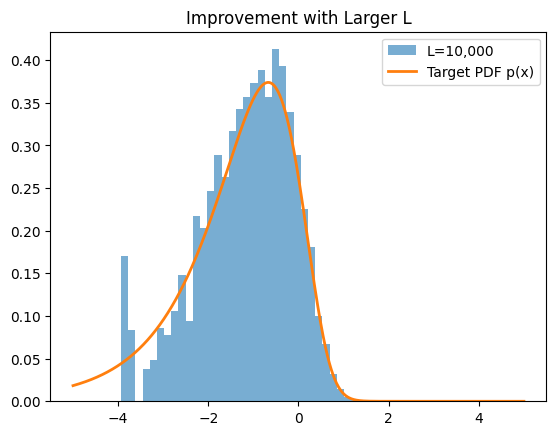

In [3]:
L_large = 10000
samples_large, weights_large = importance_sampling(L_large)

plt.hist(samples_large, bins=50, weights=weights_large, density=True, alpha=0.6, label="L=10,000")
plt.plot(x, target, label="Target PDF p(x)", linewidth=2)
plt.legend()
plt.title("Improvement with Larger L")
plt.show()


Adjusting the Proposal

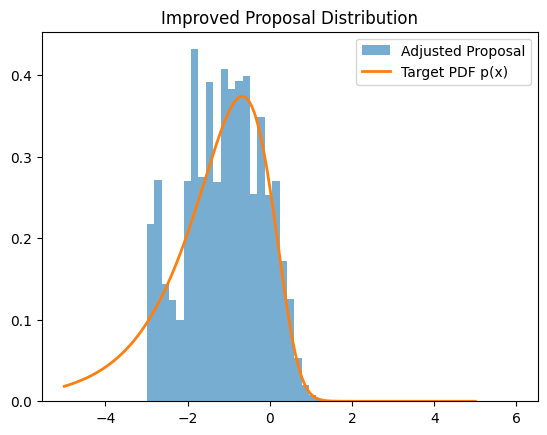

In [4]:
def better_proposal_pdf(x):
    return (1 / np.sqrt(2 * np.pi * 2)) * np.exp(-0.5 * (x - 1)**2 / 2)

def better_importance_sampling(L):
    samples = np.random.normal(1, np.sqrt(2), L)
    weights = target_pdf(samples) / better_proposal_pdf(samples)
    return samples, weights

samples_better, weights_better = better_importance_sampling(L)

plt.hist(samples_better, bins=50, weights=weights_better, density=True, alpha=0.6, label="Adjusted Proposal")
plt.plot(x, target, label="Target PDF p(x)", linewidth=2)
plt.legend()
plt.title("Improved Proposal Distribution")
plt.show()


Estimating Mean and Variance

In [5]:
mean_estimate = np.sum(weights * samples) / np.sum(weights)
variance_estimate = np.sum(weights * (samples - mean_estimate) ** 2) / np.sum(weights)

print(f"Estimated Mean: {mean_estimate:.3f}, True Mean: -1.41")
print(f"Estimated Variance: {variance_estimate:.3f}, True Variance: 1.98")


Estimated Mean: -1.048, True Mean: -1.41
Estimated Variance: 0.858, True Variance: 1.98


Using a Uniform Proposal

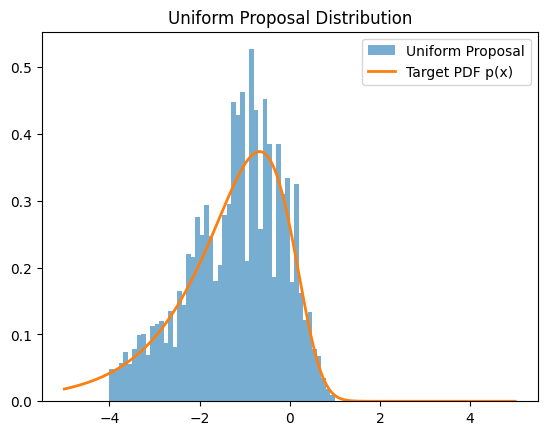

In [7]:
def uniform_proposal_pdf(x):
    return np.where((-4 <= x) & (x <= 1), 1 / 5, 0)

def uniform_importance_sampling(L):
    samples = np.random.uniform(-4, 1, L)
    weights = target_pdf(samples) / uniform_proposal_pdf(samples)
    return samples, weights

samples_uniform, weights_uniform = uniform_importance_sampling(L)

plt.hist(samples_uniform, bins=50, weights=weights_uniform, density=True, alpha=0.6, label="Uniform Proposal")
plt.plot(x, target, label="Target PDF p(x)", linewidth=2)
plt.legend()
plt.title("Uniform Proposal Distribution")
plt.show()


EXERCISE 2

Implement and simulate the Markov chain

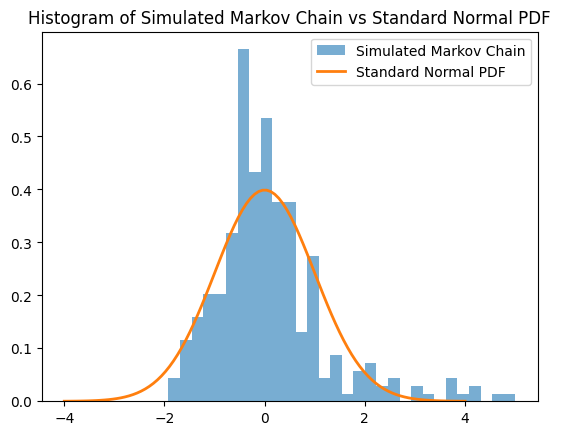

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
L = 300  # Number of time steps
x = np.zeros(L)
x[0] = 5  # Initial value
v_variance = 0.19

# Simulate the Markov chain
np.random.seed(42)
for k in range(1, L):
    v_k = np.random.normal(0, np.sqrt(v_variance))  # v[k] ~ N(0, 0.19)
    x[k] = 0.9 * x[k-1] + v_k

# Plot histogram of x and compare with standard normal PDF
plt.hist(x, bins=30, density=True, alpha=0.6, label="Simulated Markov Chain")
x_vals = np.linspace(-4, 4, 100)
pdf_standard_normal = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_vals**2)
plt.plot(x_vals, pdf_standard_normal, label="Standard Normal PDF", linewidth=2)
plt.legend()
plt.title("Histogram of Simulated Markov Chain vs Standard Normal PDF")
plt.show()


Plot the Time Series and Determine Burn-in Period

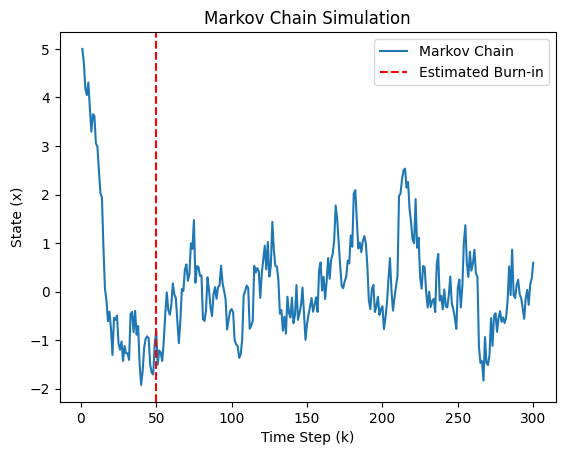

In [9]:
plt.plot(range(1, L+1), x, label="Markov Chain")
plt.axvline(50, color="red", linestyle="--", label="Estimated Burn-in")
plt.title("Markov Chain Simulation")
plt.xlabel("Time Step (k)")
plt.ylabel("State (x)")
plt.legend()
plt.show()


EXERCISE 3

KL Divergence for Two Scalar Gaussians

In [10]:
import numpy as np

def kl_divergence_scalar(mu, sigma2, m, s2):
    term1 = sigma2 / s2
    term2 = ((m - mu) ** 2) / s2
    term3 = np.log(s2 / sigma2)
    return 0.5 * (term1 + term2 - 1 + term3)

# Example Parameters
mu, sigma2 = 0, 1        # p(x): N(0, 1)
m, s2 = 1, 2             # q(x): N(1, 2)

kl_scalar = kl_divergence_scalar(mu, sigma2, m, s2)
print(f"KL Divergence (Scalar Gaussians): {kl_scalar:.4f}")


KL Divergence (Scalar Gaussians): 0.3466


KL Divergence for Two Multivariate Gaussians

In [12]:
import numpy as np

def kl_divergence_multivariate(mu, Sigma, m, S):
    k = len(mu)  # Dimensionality
    S_inv = np.linalg.inv(S)
    diff = mu - m

    term1 = np.trace(S_inv @ Sigma)
    term2 = diff.T @ S_inv @ diff
    term3 = np.log(np.linalg.det(S) / np.linalg.det(Sigma))

    return 0.5 * (term1 + term2 - k + term3)

# Example Parameters
mu = np.array([0, 0])                       # Mean of p(x)
Sigma = np.array([[1, 0.5], [0.5, 1]])      # Covariance of p(x)

m = np.array([1, 1])                        # Mean of q(x)
S = np.array([[2, 0.3], [0.3, 2]])          # Covariance of q(x)

kl_multivariate = kl_divergence_multivariate(mu, Sigma, m, S)
print(f"KL Divergence (Multivariate Gaussians): {kl_multivariate:.4f}")


KL Divergence (Multivariate Gaussians): 0.7335
